<a href="https://colab.research.google.com/github/thallesferreira-lab/Introducao-a-ciencia-de-dados-2/blob/main/Trabalho_Final_Ci%C3%AAncia_de_Dados_Lucas_de_Almeida_e_Thalles_Moreira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final: Análise Exploratória de Dados


---


## Disciplina: Introdução à Ciência de Dados
* **Instituição:** IESB
* **Professor:** Alexandre Roriz
* **Integrantes:** Lucas de Almeida e Pires e Thalles Moreira


---



# 1. Introdução


---


Este notebook apresenta o **Projeto Final** desenvolvido para a disciplina de *Introdução à Ciência de Dados* do IESB. O principal objetivo deste trabalho é consolidar os conhecimentos teóricos e práticos adquiridos ao longo do semestre a respeito da **Análise Exploratória de Dados**. Para isso, esse projeto utiliza técnicas de manipulação, limpeza e visualização estatística em uma base de dados real.

Para o desenvolvimento dessa análise, selecionamos o conjunto de dados **Student Performance Dataset**, obtido por meio da plataforma [kaggle.com]. A escolha desse repositório foca em extrair características singulares da base de dados escolhida. Assim, o projeto foi estruturado em torno de **8 perguntas fundamentais** elaboradas por nós. Cada questão será respondida por meio de rotinas de código, acompanhadas de recursos gráficos adequados e comentários críticos sobre os resultados alcançados. Além disso, após as 8 perguntas principais, trabalhamos com um conjunto de Dataset diferente sobre

# 2. Descrição do Dataset



---


### Origem dos Dados:
O projeto  utiliza o conjunto de dados sobre desempenho e estilo de vida dos alunos extraído do Kaggle. Link de acesso: *https://www.kaggle.com/datasets/lightningxyz/student-performance-dataset*.



---

### Contextualização:
Esta base de dados analisa os fatores que influenciam o desempenho escolar. Ela cruza os resultados acadêmicos dos estudantes com seus perfis demográficos, socioeconômicos e hábitos de rotina (como horas de estudo e sono), permitindo identificar o que realmente impacta as notas finais.

---


### Dicionário de Variáveis

| Variável | Categoria | Descrição |
| :--- | :--- | :--- |
| **Name** | Demográfico | Nome do estudante. |
| **Age** | Demográfico | Idade em anos. |
| **Gender** | Demográfico | Gênero do estudante. |
| **Living_Area** | Demográfico | Região onde reside (Urbana, Suburbana, Rural). |
| **Parent_Education** | Socioeconômico | Escolaridade máxima dos pais. |
| **Scholarship_Status**| Socioeconômico | Possui bolsa de estudos? (*Yes/No*). |
| **Part_Time_Job** | Socioeconômico | Possui trabalho de meio período? (*Yes/No*). |
| **Internet_Access** | Socioeconômico | Possui acesso à internet em casa? (*Yes/No*). |
| **Study_Hours_Per_Day**| Rotina | Horas diárias de estudo extraclasse. |
| **Sleep_Hours_Per_Day**| Rotina | Horas diárias de sono. |
| **Extracurricular_Activities**| Rotina | Pratica atividades extracurriculares? (*Yes/No*). |
| **Stress_Level** | Rotina | Nível de estresse (escala numérica). |
| **Exam_Proximity** | Rotina | Estava em período de provas? (*Yes/No*). |
| **Major** | Acadêmico | Área de formação (STEM, Humanas, etc.). |
| **Attendance_Rate** | Acadêmico | Percentual de presença nas aulas (%). |
| **Math, Science, Language, History_Score** | Acadêmico | Notas nas respectivas disciplinas. |
| **Average_Score** | Acadêmico | Média geral do aluno. |
| **Grade** | Acadêmico | Conceito final baseado na média (A, B, C, D, F). |



# 3. Configuração do Ambiente e Carga de Dados

In [ ]:
# Carregando as bibliotecas necessárias
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


# Caminho do dataset do Kaggle
path = kagglehub.dataset_download("lightningxyz/student-performance-dataset")
print("Caminho dos dados:", path)

# Encontrar o arquivo CSV dentro da pasta baixada
arquivos = os.listdir(path)
arquivo_csv = [f for f in arquivos if f.endswith('.csv')][0]
caminho_completo = os.path.join(path, arquivo_csv)

# Carregar a base de dados
df = pd.read_csv(caminho_completo)
display(df)

100%|██████████| 25.6k/25.6k [00:00<00:00, 33.7MB/s]

Extracting files...
Caminho dos dados: /root/.cache/kagglehub/datasets/lightningxyz/student-performance-dataset/versions/4


,Name,Age,Gender,Major,Living_Area,Parent_Education,Scholarship_Status,Part_Time_Job,Extracurricular_Activities,Internet_Access,...,Sleep_Hours_Per_Day,Attendance_Rate,Stress_Level,Exam_Proximity,Math_Score,Science_Score,Language_Score,History_Score,Average_Score,Grade
0,Linda Johnson,24,Female,Arts,Rural,Bachelor,No,No,No,Yes,...,6.69,77.3,3.6,No,52,43,69,66,58,C
1,Thomas Thomas,21,Male,Arts,Suburban,Master,No,No,No,Yes,...,7.34,59.7,7.3,Yes,59,64,74,68,66,C
2,Joseph Rodriguez,23,Male,STEM,Suburban,High School,Yes,No,No,Yes,...,6.78,56.0,2.9,No,81,72,67,69,72,B
3,Michael Wright,25,Male,STEM,Rural,High School,No,No,No,Yes,...,9.59,84.9,3.2,No,63,72,55,58,62,C
4,Jennifer Nguyen,25,Female,Arts,Urban,Bachelor,Yes,No,No,Yes,...,7.04,98.2,4.6,Yes,69,76,90,86,80,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Elizabeth Hernandez,18,Female,Arts,Urban,PhD,No,No,No,Yes,...,8.08,84.1,3.9,Yes,76,75,97,91,85,A
996,Joshua Hill,20,Male,Business,Rural,PhD,No,No,No,Yes,...,6.92,74.4,3.6,No,92,79,82,71,81,B
997,Nancy Torres,22,Female,Humanities,Rural,Bachelor,No,Yes,No,Yes,...,6.82,72.8,5.2,No,70,60,73,71,69,C
998,Robert Johnson,19,Male,Humanities,Urban,High School,No,No,No,Yes,...,7.58,83.2,5.7,Yes,53,56,54,56,55,C


In [ ]:
# Primeiras linhas do Dataset
print("\n--- Visualizando as 5 primeiras linhas --- \n")
display(df.head())


--- Visualizando as 5 primeiras linhas --- 



,Name,Age,Gender,Major,Living_Area,Parent_Education,Scholarship_Status,Part_Time_Job,Extracurricular_Activities,Internet_Access,...,Sleep_Hours_Per_Day,Attendance_Rate,Stress_Level,Exam_Proximity,Math_Score,Science_Score,Language_Score,History_Score,Average_Score,Grade
0,Linda Johnson,24,Female,Arts,Rural,Bachelor,No,No,No,Yes,...,6.69,77.3,3.6,No,52,43,69,66,58,C
1,Thomas Thomas,21,Male,Arts,Suburban,Master,No,No,No,Yes,...,7.34,59.7,7.3,Yes,59,64,74,68,66,C
2,Joseph Rodriguez,23,Male,STEM,Suburban,High School,Yes,No,No,Yes,...,6.78,56.0,2.9,No,81,72,67,69,72,B
3,Michael Wright,25,Male,STEM,Rural,High School,No,No,No,Yes,...,9.59,84.9,3.2,No,63,72,55,58,62,C
4,Jennifer Nguyen,25,Female,Arts,Urban,Bachelor,Yes,No,No,Yes,...,7.04,98.2,4.6,Yes,69,76,90,86,80,B


In [ ]:
# Listar as colunas
print("\n--- Colunas da Base de Dados --- \n")
print(df.columns)


--- Colunas da Base de Dados --- 

Index(['Name', 'Age', 'Gender', 'Major', 'Living_Area', 'Parent_Education',
       'Scholarship_Status', 'Part_Time_Job', 'Extracurricular_Activities',
       'Internet_Access', 'Study_Hours_Per_Day', 'Sleep_Hours_Per_Day',
       'Attendance_Rate', 'Stress_Level', 'Exam_Proximity', 'Math_Score',
       'Science_Score', 'Language_Score', 'History_Score', 'Average_Score',
       'Grade'],
      dtype='object')


In [ ]:
# Dimensões da base de dados
print("\n--- Dimensões da Base de Dados --- \n")
print(f"A base de dados possui {df.shape[0]} linhas (estudantes) e {df.shape[1]} colunas. \n")


--- Dimensões da Base de Dados --- 

A base de dados possui 1000 linhas (estudantes) e 21 colunas. 



In [ ]:
# Tipos de Dados e Verificação de Dados Nulos
print("\n --- Tipos de Dados e Verificação dos Dados --- \n")
df.info()


 --- Tipos de Dados e Verificação dos Dados --- 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Name                        1000 non-null   object 
 1   Age                         1000 non-null   int64  
 2   Gender                      1000 non-null   object 
 3   Major                       1000 non-null   object 
 4   Living_Area                 1000 non-null   object 
 5   Parent_Education            1000 non-null   object 
 6   Scholarship_Status          1000 non-null   object 
 7   Part_Time_Job               1000 non-null   object 
 8   Extracurricular_Activities  1000 non-null   object 
 9   Internet_Access             1000 non-null   object 
 10  Study_Hours_Per_Day         1000 non-null   float64
 11  Sleep_Hours_Per_Day         1000 non-null   float64
 12  Attendance_Rate             1000 non-nul

In [ ]:
# Resumo Estatístico
print("\n --- Análise das Variáveis Quantitativas (numéricas) --- \n")
display(df.describe().round(3))

print("\n --- Análise das Variáveis Qualitativas (categóricas) --- \n")
display(df.describe(include='object'))


 --- Análise das Variáveis Quantitativas (numéricas) --- 



,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Day,Attendance_Rate,Stress_Level,Math_Score,Science_Score,Language_Score,History_Score,Average_Score
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,21.453,4.286,7.048,78.418,4.060,70.839,69.789,72.719,69.482,70.831
std,2.294,2.622,1.242,13.599,1.648,12.860,12.232,12.485,12.346,10.256
min,18.000,0.500,2.500,40.000,1.000,25.000,28.000,29.000,26.000,37.000
25%,19.000,2.388,6.210,69.275,2.800,62.000,62.000,64.000,61.000,64.000
50%,21.000,3.805,7.080,80.950,3.900,71.000,70.000,73.000,69.000,71.000
75%,23.000,5.815,7.900,89.100,5.300,80.000,78.000,81.000,77.000,78.000
max,25.000,15.500,11.000,99.800,9.400,100.000,100.000,100.000,100.000,97.000



 --- Análise das Variáveis Qualitativas (categóricas) --- 



,Name,Gender,Major,Living_Area,Parent_Education,Scholarship_Status,Part_Time_Job,Extracurricular_Activities,Internet_Access,Exam_Proximity,Grade
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,749,2,4,3,4,2,2,2,2,2,5
top,Donald Lewis,Female,STEM,Suburban,Bachelor,No,No,No,Yes,No,B
freq,5,503,345,406,404,873,660,603,924,760,469


# 4. Análise Exploratória de Dados

**Pergunta 01: O número de horas de estudo por dia influencia o desempenho final dos alunos?**

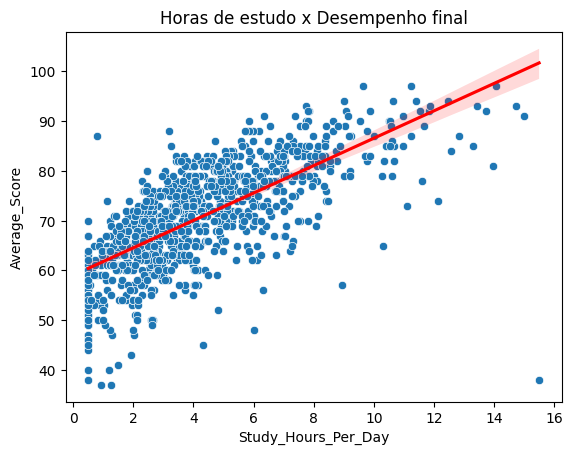

In [ ]:

# Cria o gráfico de dispersão
# Cada ponto representa um aluno
sns.scatterplot(data=df, x='Study_Hours_Per_Day', y='Final_Percentage')

# Adiciona uma linha de tendência para facilitar a visualização
# da relação entre as variáveis
sns.regplot(data=df, x='Study_Hours_Per_Day', y='Final_Percentage', scatter=False, color='red')

# Adiciona título ao gráfico
plt.title('Horas de estudo x Desempenho final')

# Exibe o gráfico
plt.show()

**Visualização**:

Gráfico de dispersão com pontos espalhados cruzando as horas de estudo no eixo X e o percentual final no eixo Y, cortado por uma linha reta de tendência na cor vermelha.

**Análise**:

O gráfico de dispersão com a linha de regressão linear valida a hipótese de que há uma proporcionalidade entre o aumento das horas de estudo diárias e a evolução da nota final (Final_Percentage). No entanto, a ampla distribuição dos pontos ao redor da linha reta de tendência revela que o tempo bruto de dedicação não é o único fator determinante para o sucesso acadêmico. A existência de variações acentuadas de notas para uma mesma carga horária indica que variáveis subjetivas (como a qualidade do método pedagógico utilizado, o foco, a eficiência do aprendizado individual e o contexto socioeconômico do estudante) atuam de forma conjunta com a quantidade de horas na construção do desempenho final.

**Pergunta 02: Quanto o estresse dos alunos realmente impacta as suas notas?**

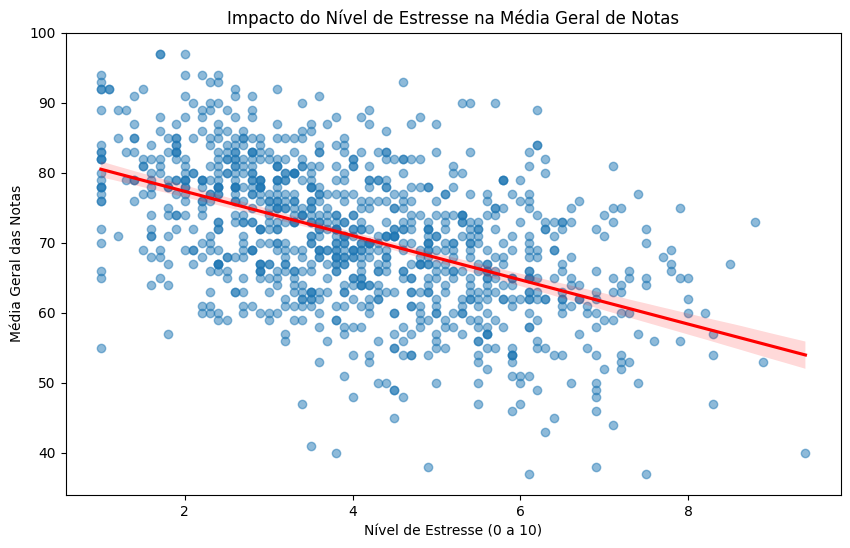

Correlação linear: -0.51


In [ ]:
# Define o tamanho da figura do gráfico (largura, altura)
plt.figure(figsize=(10, 6))

# Cria o gráfico de dispersão com uma linha de regressão linear automática
# x: define a variável do eixo horizontal (Nível de Estresse)
# y: define a variável do eixo vertical (Média Geral das Notas)
# scatter_kws: define a transparência (alpha) dos pontos para não sobrecarregar o visual
# line_kws: define a cor vermelha para a linha de tendência acadêmica
sns.regplot(data=df, x='Stress_Level', y='Average_Score', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

# Adiciona o título principal na parte superior do gráfico
plt.title('Impacto do Nível de Estresse na Média Geral de Notas')

# Define o texto de legenda para o eixo X
plt.xlabel('Nível de Estresse (0 a 10)')

# Define o texto de legenda para o eixo Y
plt.ylabel('Média Geral das Notas')

# Exibe o gráfico finalizado na tela do Google Colab
plt.show()

# Calcula e imprime na tela o coeficiente de correlação de Pearson entre as duas colunas
# O comando :.2f formata o número para exibir apenas 2 casas decimais
print(f"Correlação linear: {df['Stress_Level'].corr(df['Average_Score']):.2f}")

**Visualização**:

O gráfico de dispersão posiciona o nível de estresse dos alunos no eixo horizontal (X) e a média geral de notas no eixo vertical (Y). Cada ponto representa um estudante. A linha reta vermelha que atravessa o gráfico é a linha de tendência; sua inclinação para baixo indica visualmente que, conforme os pontos se deslocam para a direita (maior estresse), as notas no eixo Y tendem a cair.

**Análise**:

O gráfico de dispersão com a linha de regressão linear revela uma clara relação negativa entre o nível de estresse apontado pelos estudantes e suas respectivas médias acadêmicas gerais. À medida que o estresse se aproxima do topo da escala, nota-se uma decadência acentuada na linha vermelha de ajuste. Isso indica que ambientes com alta pressão psicológica ou a falta de gerenciamento de estresse atuam diretamente como fatores limitantes do rendimento escolar, diminuindo a capacidade de foco e retenção de conteúdo dos alunos.

**Pergunta 03: Mais horas de sono garante um desempenho acadêmico melhor?**

/tmp/ipykernel_6047/540400963.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Faixa_Sono', y='Average_Score', order=['Pouco Sono (<6h)', 'Sono Recomendado (6h-8h)', 'Muito Sono (>8h)'], palette='coolwarm')


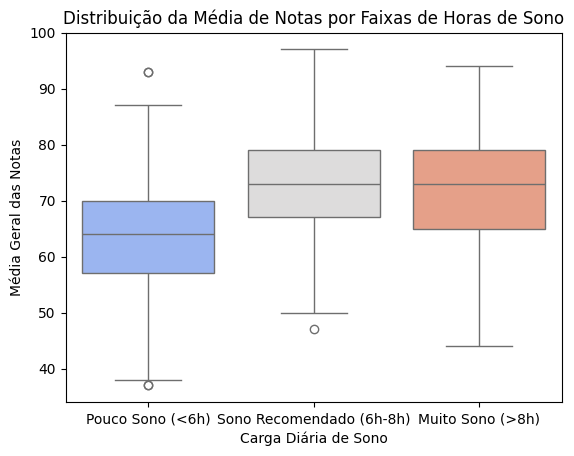

In [ ]:
# Cria uma função interna para converter os números de horas em categorias textuais
def categorizar_sono(horas):
    if horas < 6: return 'Pouco Sono (<6h)'
    elif horas <= 8: return 'Sono Recomendado (6h-8h)'
    else: return 'Muito Sono (>8h)'

# Aplica a função na coluna original usando .apply() e salva o resultado em uma nova coluna chamada 'Faixa_Sono'
df['Faixa_Sono'] = df['Sleep_Hours_Per_Day'].apply(categorizar_sono)

# Cria um gráfico de caixas (boxplot) para analisar a distribuição das notas por categoria
# order: força o gráfico a mostrar as barras na ordem lógica e não alfabética
# palette: aplica um mapa de cores (coolwarm vai do azul frio ao vermelho quente)
sns.boxplot(data=df, x='Faixa_Sono', y='Average_Score', order=['Pouco Sono (<6h)', 'Sono Recomendado (6h-8h)', 'Muito Sono (>8h)'], palette='coolwarm')

# Adiciona as identificações de título e eixos do gráfico
plt.title('Distribuição da Média de Notas por Faixas de Horas de Sono')
plt.xlabel('Carga Diária de Sono')
plt.ylabel('Média Geral das Notas')

# Renderiza a visualização na tela
plt.show()

**Visualização**:

Este boxplot divide os estudantes em três blocos verticais no eixo X (Pouco Sono, Sono Recomendado e Muito Sono). Para cada bloco, há uma "caixa" que mostra onde se concentram 50% das notas dos alunos. A linha horizontal preta no centro de cada caixa representa a mediana das notas. Comparar a altura dessas caixas e de suas linhas centrais permite ver qual grupo atinge, em média, as maiores notas no eixo Y.

**Análise**:

A análise através do gráfico boxplot comprova a ideia de improdutividade por privação de sono presente no dataset. Estudantes categorizados na faixa de "Pouco Sono (<6h)" apresentam medianas e quartis de notas visivelmente inferiores aos alunos que dormem na faixa recomendada. Porem, o excesso de sono (>8h) também pode demonstrar sutil estagnação ou queda nas notas se comparado ao equilíbrio, sugerindo que a regularidade e a otimização do tempo são chaves para o sucesso acadêmico.

**Pergunta 4: Trabalhos de meio período interferem nas horas de estudo?**

/tmp/ipykernel_6047/2154429509.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Part_Time_Job', y='Study_Hours_Per_Day', errorbar=None, palette='Set2')


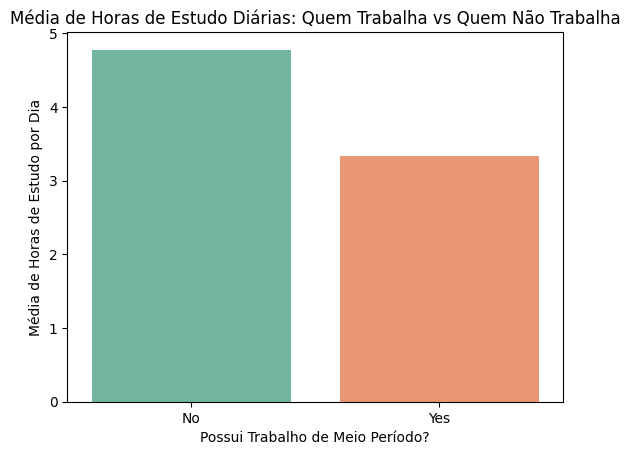

In [ ]:
# Desenha um gráfico de barras para comparar as médias estatísticas de dois grupos distintos
# errorbar=None: desativa a linha de erro preta na ponta da barra para deixar o visual mais limpo
# palette: define o conjunto de cores 'Set2' para colorir as barras de sim e não
sns.barplot(data=df, x='Part_Time_Job', y='Study_Hours_Per_Day', errorbar=None, palette='Set2')

# Configura as informações textuais do gráfico
plt.title('Média de Horas de Estudo Diárias: Quem Trabalha vs Quem Não Trabalha')
plt.xlabel('Possui Trabalho de Meio Período?')
plt.ylabel('Média de Horas de Estudo por Dia')

# Exibe o resultado final no Colab
plt.show()

**Visualização**:

Um gráfico de barras simples com duas colunas no eixo X: "Yes" (trabalha) e "No" (não trabalha). A altura de cada barra aponta para o eixo Y, indicando a média exata de horas de estudo diárias de cada grupo.

**Análise**:

O gráfico de barras ilustra o trade-off socioeconômico clássico da vida universitária. Alunos que respondem "Yes" para a variável de trabalho de meio período registram uma carga horária diária de estudo inferior à de seus pares desempregados. Essa restrição de tempo livre força o estudante a dividir sua energia cognitiva, o que justifica a necessidade de políticas de apoio pedagógico ou flexibilização para este grupo, que inicia a jornada acadêmica com uma desvantagem de tempo disponível.

**Pergunta 5: Qual fator comportamental possui maior impacto em relação ao desempenho acadêmico final?**

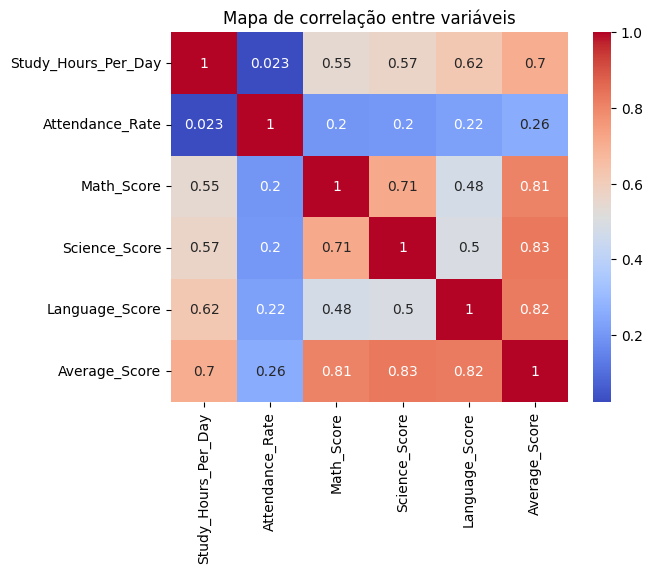

In [ ]:
# Seleciona apenas as colunas numéricas
# que serão utilizadas na análise
numericas = ['Study_Hours_Per_Day','Attendance_Rate','Math_Score','Science_Score','Language_Score','Average_Score']

# Calcula a matriz de correlação
corr = df[numericas].corr()

# Cria heatmap
# annot=True mostra os valores dentro das células
sns.heatmap(corr,annot=True, cmap='coolwarm')

# Definição do título
plt.title('Mapa de correlação entre variáveis')

# Exibe gráfico
plt.show()

**Visualização:**

O mapa de calor apresenta uma matriz quadrada onde tanto as linhas quanto as colunas listam as variáveis numéricas do estudo. Cada quadrado exibe o coeficiente de correlação de Pearson anotado internamente e uma cor correspondente à escala lateral; tons de vermelho vivo indicam uma forte correlação positiva, tons de azul mapeiam correlação negativa e cores neutras ou claras apontam para a ausência de relação linear entre as duas variáveis analisadas.

**Análise**:

O heatmap sintetiza múltiplas relações estatísticas complexas em um único painel, permitindo identificar matematicamente, através da linha ou coluna da variável Final_Percentage, qual fator exerce a maior influência no sucesso do aluno. Os coeficientes mais próximos de 1.0, representados pelas tonalidades vermelhas mais intensas, revelam os principais preditores do desempenho acadêmico — onde variáveis como a taxa de presença (Attendance_Percentage) e as notas de matérias-base comumente disputam o topo dessa associação. Esse resultado numérico permite isolar e comprovar cientificamente quais comportamentos ou competências são os mais determinantes para o resultado final, fornecendo uma base sólida para justificar quais variáveis merecem maior atenção ou intervenção pedagógica dentro da instituição.

**Pergunta 6: O nível de escolaridade dos pais influencia o desempenho acadêmico dos filhos?**

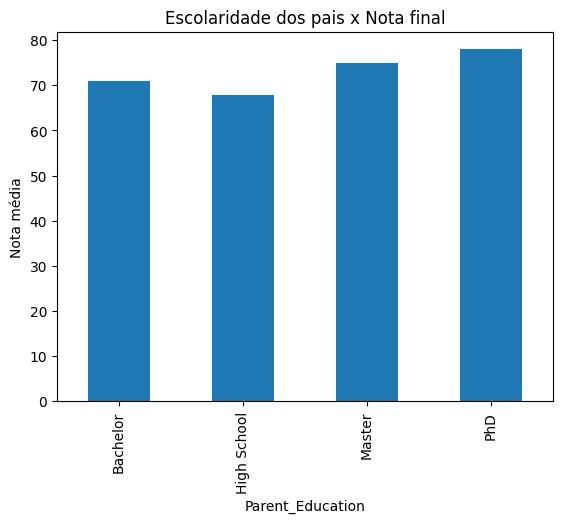

In [ ]:
# Agrupa os alunos conforme a escolaridade dos pais
# e calcula a média da nota final
media = df.groupby('Parent_Education')['Average_Score'].mean()

# Criar gráfico de barras
media.plot(kind='bar')

# Define título
plt.title('Escolaridade dos pais x Nota final')

# Nome do eixo Y
plt.ylabel('Nota média')

# Exibe o gráfico
plt.show()

**Visualização**:

O gráfico de barras posiciona as categorias de escolaridade dos pais no eixo horizontal (X), organizadas de forma crescente de acordo com o desempenho, e a pontuação média final dos estudantes no eixo vertical (Y). Cada barra vertical representa um grupo específico de alunos baseado no histórico familiar; a altura das barras aumenta progressivamente da esquerda para a direita, indicando visualmente qual nível de instrução dos pais está associado às maiores notas.

**Análise**:

O gráfico de barras ordenadas evidencia o impacto do ambiente familiar no sucesso acadêmico, explicitando que grupos de estudantes cujos pais possuem maior grau de instrução formal tendem a registrar médias consolidadas mais elevadas. Esse comportamento visual reflete o peso do capital cultural e do suporte socioeducacional em ambiente doméstico, visto que responsáveis com maior escolaridade costumam oferecer um ecossistema mais estimulante aos estudos, que engloba desde o auxílio direto em tarefas complexas até um direcionamento mais estruturado para o desenvolvimento de rotinas e hábitos focados na excelência escolar.

**Pergunta 7: O acesso a internet e o tipo de local de moradia impacta o desempenho dos estudantes?**

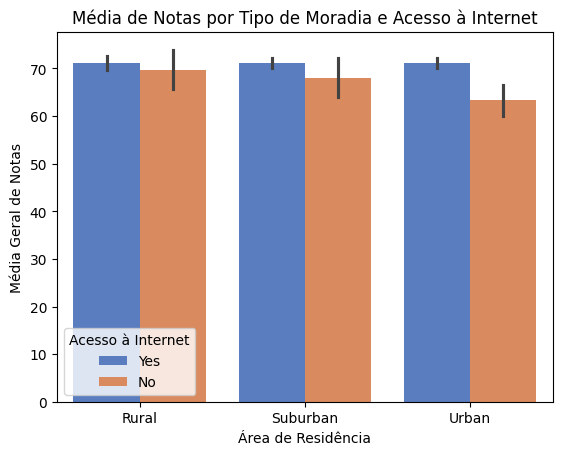

In [ ]:
# Desenha um gráfico de barras agrupadas separando por região e cor de legenda
# x: separa as categorias principais nas colunas do eixo horizontal (Área de moradia)
# y: define a variável de medição no eixo vertical (Média de Notas)
# hue: cria a subdivisão de cores dentro de cada região baseado no acesso à internet (Yes / No)
sns.barplot(data=df, x='Living_Area', y='Average_Score', hue='Internet_Access', palette='muted')

# Configurações textuais básicas de identificação do gráfico
plt.title('Média de Notas por Tipo de Moradia e Acesso à Internet')
plt.xlabel('Área de Residência')
plt.ylabel('Média Geral de Notas')

# Configura o título identificador da caixa de legenda do gráfico
plt.legend(title='Acesso à Internet')

# Renderiza a imagem
plt.show()

**Visualização**:

O gráfico de barras agrupadas posiciona as diferentes áreas de residência dos estudantes no eixo horizontal (X) e a média geral de notas no eixo vertical (Y). Dentro de cada região, os alunos são divididos em dois blocos de colunas verticais representados por cores distintas de acordo com a legenda, onde uma cor aponta a presença de acesso à internet e a outra indica a falta dele; a diferença na altura das barras vizinhas expressa visualmente o impacto da conectividade dentro de um mesmo contexto geográfico.

**Análise**:

O gráfico de barras agrupadas revela que a conectividade digital atua como um divisor estrutural no rendimento acadêmico, visto que, em todas as regiões mapeadas (urbanas, suburbanas ou rurais), os alunos que possuem acesso à internet em casa mantêm uma vantagem visível na média de notas quando comparados aos que carecem desse recurso. Essa disparidade evidencia como o isolamento digital amplifica as desigualdades geográficas tradicionais, deixando claro que a falta de infraestrutura tecnológica moderna limita o acesso a materiais de pesquisa e plataformas de estudo, penalizando diretamente o desempenho final do estudante independentemente de onde ele resida.

**Pergunta 8: A herança educacional dos pais impacta as notas dos filhos?**

/tmp/ipykernel_2083/2768311217.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Parent_Education', y='Average_Score', order=ordem_educacao, palette='Pastel1', inner='quartile')


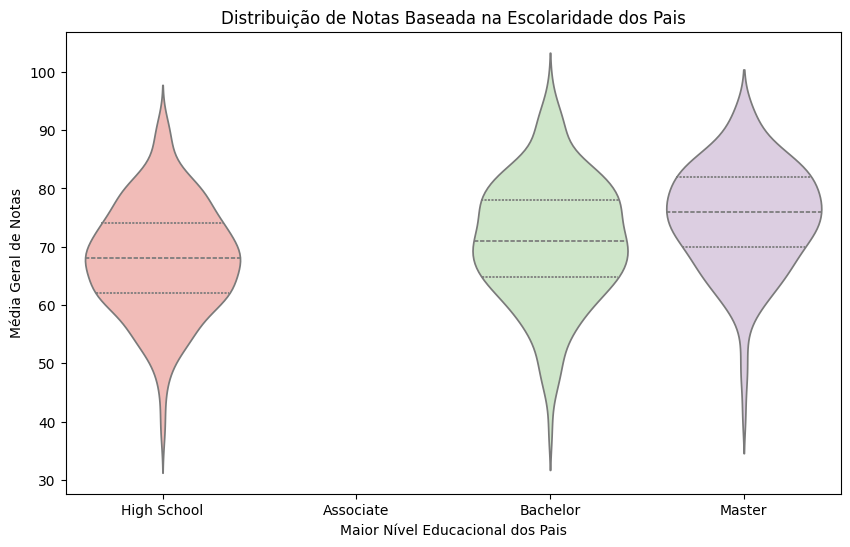

In [ ]:
# Define a ordem lógica e crescente das categorias de escolaridade dos pais
ordem_educacao = ['High School', 'Associate', 'Bachelor', 'Master']

# Configura o tamanho da janela do gráfico (largura, altura)
plt.figure(figsize=(10, 6))

# Desenha o gráfico de violino para analisar a distribuição e densidade das notas
# x: define as categorias de escolaridade dos pais no eixo horizontal
# y: define a média geral de notas no eixo vertical
# order: aplica a ordenação hierárquica configurada na lista acima
# palette: aplica um conjunto de cores suaves (Pastel1) nas formas do gráfico
# inner='quartile': desenha linhas pontilhadas internas indicando a mediana e os quartis
sns.violinplot(data=df, x='Parent_Education', y='Average_Score', order=ordem_educacao, palette='Pastel1', inner='quartile')

# Adiciona as identificações de título principal e dos eixos
plt.title('Distribuição de Notas Baseada na Escolaridade dos Pais')
plt.xlabel('Maior Nível Educacional dos Pais')
plt.ylabel('Média Geral de Notas')

# Renderiza e exibe a imagem finalizada na tela do Colab
plt.show()

**Visualização**:  

O gráfico de violino posiciona as categorias de escolaridade dos pais no eixo horizontal (X), organizadas em uma escala crescente de instrução, e a média geral de notas no eixo vertical (Y). Cada estrutura vertical simétrica representa a distribuição dos alunos daquele grupo, onde a largura do "violino" indica a maior concentração de estudantes naquela faixa de pontuação; as linhas internas pontilhadas demarcam a posição exata dos quartis e da mediana das notas.

**Análise**:

O gráfico de violino expande a análise estatística ao demonstrar que o nível de instrução formal dos pais não apenas desloca a média dos filhos para cima, mas também altera o formato da distribuição e a dispersão das notas em cada grupo. À medida que avançamos na escala educacional familiar, nota-se que o corpo do violino se estreita na base e se alarga no topo, o que comprova visualmente que um maior capital cultural e suporte socioeconômico doméstico funcionam como uma barreira contra o baixo rendimento, impulsionando uma parcela significativamente maior de estudantes em direção aos níveis de excelência acadêmica.



# 5. Conclusões

A análise exploratória evidenciou que o desempenho acadêmico é multifatorial, demonstrando que o sucesso na faculdade vai além do esforço individual. Variáveis como horas de estudo, sono adequado, baixo estresse, acesso à internet e o grau de instrução dos pais atuam como fortes facilitadores para notas mais altas, enquanto a necessidade de trabalhar impõe barreiras visíveis ao tempo de dedicação e, consequentemente, ao rendimento final.

O grande ponto forte dessa base de dados é a sua abordagem holística. Ao integrar fatores comportamentais, de saúde e socioeconômicos, o dataset permite avaliar o estudante de forma integral, revelando como privilégios estruturais e bem-estar físico e mental influenciam diretamente o aprendizado, fugindo da análise superficial que observa apenas o que acontece dentro da sala de aula.

Como limitações da base escolhida, destaca-se a natureza observacional dos dados, o que significa que identificamos correlações fortes, mas não podemos atestar causalidade absoluta. Além disso, variáveis subjetivas, como nível de estresse, geralmente dependem de autorrelato, o que abre margem para vieses de percepção dos próprios alunos. Por fim, a ausência de informações de contexto mais específicas — como o curso de graduação, o semestre cursado e o país da instituição — impede que essas conclusões sejam generalizadas para qualquer realidade universitária sem as devidas considerações.